In this file, we want to perform some calculations of the level shift function for ensembles of atoms of varying size with different transition frequencies.  Ideally, we can come up with a general way of calculating the level shift function that doesn't scale poorly with the number of atoms.  Also, we want to see if we can get the transfer function from the level shift function and plot what that looks like if we can.

### Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.cm as cm
import qutip as qu

In [2]:
# Set font size of plot elements\n",
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

### Functions

### Main Results
The level shift function should be $R_x(z) = \sum_{y\neq x}V_{xy}\frac{1}{z-E_y}V_{yx}$.  If possible, I would like to verify that the fourth order term in the sum seems to generally be 0 as well.  We'll start by doing the calculations with full matrices for a few atoms, but we'll have to develop a more efficient way later for handling larger numbers of atoms.

In [3]:
# Define parameters - we'll assume for now that the coupling strengths and decay rates are uniform
g10 = 5
g21 = 1
κ = 1
γ10 = 1
γ21 = 0.05
N = 2

In [4]:
# Define the transition frequencies using a gaussian distribution
Δω = 1
rng = np.random.default_rng(seed=15)
ω21s = rng.normal(loc=5, scale=Δω, size=N)
ω10s = rng.normal(loc=2, scale=Δω, size=N)
ωc = 5

In [5]:
print("ω21s: ", ω21s)
print("ω10s: ", ω10s)

ω21s:  [3.56912698 4.06345228]
ω10s:  [2.39393836 1.47591337]


In [6]:
# Now define the operators that we'll be using
σ10 = qu.Qobj([[0, 1, 0],
               [0, 0, 0],
               [0, 0, 0]])
σ21 = qu.Qobj([[0, 0, 0],
               [0, 0, 1],
               [0, 0, 0]])
a = qu.destroy(2)

# Also define the identity operators for ease of use
Ic = qu.qeye(2)
I0 = qu.qeye(3)
I1 = qu.qeye(3)

In [7]:
# Define Hamiltonian
H0 = ωc * qu.tensor([a.dag() * a, I0, I1]) 
H0 += ω10s[0] * qu.tensor([Ic, σ10.dag() * σ10, I1]) + ω10s[1] * qu.tensor([Ic, I0, σ10.dag() * σ10])
H0 += ω21s[0] * qu.tensor([Ic, σ21.dag() * σ21, I1]) + ω21s[1] * qu.tensor([Ic, I0, σ21.dag() * σ21])
H0

Quantum object: dims=[[2, 3, 3], [2, 3, 3]], shape=(18, 18), type='oper', dtype=Dia, isherm=True
Qobj data =
[[ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 0.          1.47591337  0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          4.06345228  0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          2.39393836  0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          3.86985173  

In [8]:
# Get the eigenstates of H0
H0_eigs = H0.eigenstates()

In [9]:
# Define interaction
V = g10 * (qu.tensor([Ic, σ10.dag(), I1]) + qu.tensor([Ic, σ10, I1]) + qu.tensor([Ic, I0, σ10.dag()]) + qu.tensor([Ic, I0, σ10]))
V += g21 * (qu.tensor([a, σ21.dag(), I1]) + qu.tensor([a.dag(), σ21, I1]) + qu.tensor([a, I0, σ21.dag()]) + qu.tensor([a.dag(), I0, σ21]))
V

Quantum object: dims=[[2, 3, 3], [2, 3, 3]], shape=(18, 18), type='oper', dtype=Dia, isherm=True
Qobj data =
[[0. 5. 0. 5. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [5. 0. 0. 0. 5. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 5. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [5. 0. 0. 0. 5. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 5. 0. 5. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 5. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 5. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 5. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 5. 0. 5. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 5. 0. 0. 0. 5. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 5. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 5. 0. 0. 0. 5. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 5. 0. 5. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 5. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

In [10]:
# Create a list of basis vectors for the cavity and each atom
cav_bas = [qu.basis(2, i) for i in range(2)]
atom_bas = [qu.basis(3, i) for i in range(3)]

In [11]:
# Now we can construct the eigenstates that we want to calculate R(z) for.  Let's start with |1,0,0>
x100 = qu.tensor([cav_bas[1], atom_bas[0], atom_bas[0]])
x100 = np.array([x100])

ind_to_exc = int(np.where(x100 == H0_eigs[1])[0][0])
ind_to_exc

6

In [12]:
mask = np.ones(H0_eigs[1].shape[0], dtype=bool)
mask[ind_to_exc] = 0
masked_states = H0_eigs[1][mask]
masked_vals = H0_eigs[0][mask]

In [13]:
# Define our z
z = np.linspace(-10, 10, 100)

R_100 = np.zeros(z.shape[0], dtype=complex)
for i in range(z.shape[0]):
    R_100[i] = np.sum([x100[0].dag() * V * masked_states[j] * 1 / (z[i] - masked_vals[j]) * masked_states[j].dag() * V * x100[0]
                      for j in range(masked_states.shape[0])])


In [14]:
# Now what if we use something like x_111?
x110 = qu.tensor([cav_bas[1], atom_bas[1], atom_bas[0]])
x110 = np.array([x110])

ind_to_exc = int(np.where(x110 == H0_eigs[1])[0][0])
ind_to_exc

10

In [15]:
mask = np.ones(H0_eigs[1].shape[0], dtype=bool)
mask[ind_to_exc] = 0
masked_states = H0_eigs[1][mask]
masked_vals = H0_eigs[0][mask]

In [16]:
# Define our z
z = np.linspace(-10, 10, 100)

R_110 = np.zeros(z.shape[0], dtype=complex)
for i in range(z.shape[0]):
    R_110[i] = np.sum([x110[0].dag() * V * masked_states[j] * 1 / (z[i] - masked_vals[j]) * masked_states[j].dag() * V * x110[0]
                      for j in range(masked_states.shape[0])])


In [17]:
# Now what if we use something like x_111?
x020 = qu.tensor([cav_bas[0], atom_bas[0], atom_bas[2]])
x020 = np.array([x020])

ind_to_exc = int(np.where(x020 == H0_eigs[1])[0][0])
ind_to_exc

5

In [18]:
mask = np.ones(H0_eigs[1].shape[0], dtype=bool)
mask[ind_to_exc] = 0
masked_states = H0_eigs[1][mask]
masked_vals = H0_eigs[0][mask]

In [19]:
# Define our z
z = np.linspace(-10, 10, 100)

R_020 = np.zeros(z.shape[0], dtype=complex)
for i in range(z.shape[0]):
    R_020[i] = np.sum([x020[0].dag() * V * masked_states[j] * 1 / (z[i] - masked_vals[j]) * masked_states[j].dag() * V * x020[0]
                      for j in range(masked_states.shape[0])])


/home/jacob/anaconda3/envs/mode_cooling/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jacob/anaconda3/envs/mode_cooling/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


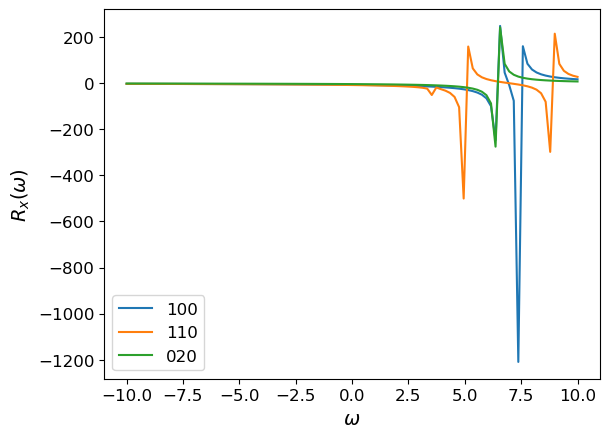

In [20]:
plt.plot(z, R_100, label='100')
plt.plot(z, R_110, label='110')
plt.plot(z, R_020, label='020')
plt.xlabel("$\\omega$")
plt.ylabel("$R_x(\\omega)$")
plt.legend()

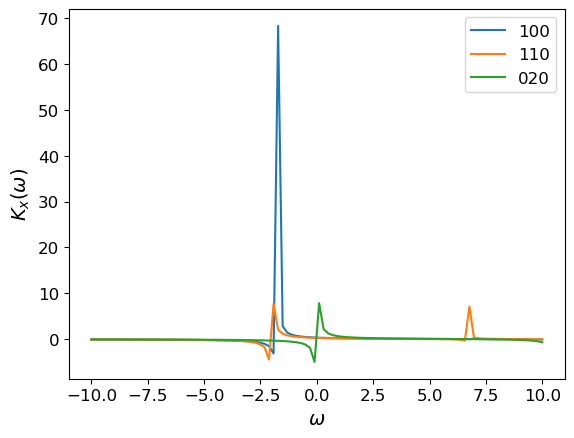

In [21]:
# Now calculate G_120(z)
K_100 = 1 / (z - H0_eigs[0][ind_to_exc] - R_100)
K_110 = 1 / (z - H0_eigs[0][ind_to_exc] - R_110)
K_020 = 1 / (z - H0_eigs[0][ind_to_exc] - R_020)
plt.plot(z, K_100, label='100')
plt.plot(z, K_110, label='110')
plt.plot(z, K_020, label='020')
plt.xlabel("$\\omega$")
plt.ylabel("$K_x(\\omega)$")
plt.legend()

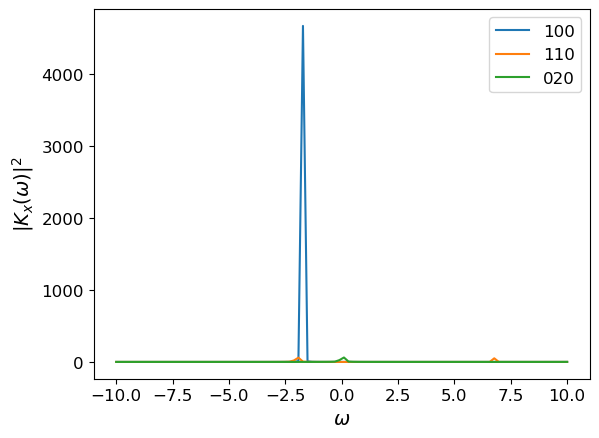

In [22]:
plt.plot(z, np.abs(K_100) ** 2, label='100')
plt.plot(z, np.abs(K_110) ** 2, label='110')
plt.plot(z, np.abs(K_020) ** 2, label='020')
plt.xlabel("$\\omega$")
plt.ylabel("$|K_x(\\omega)|^2$")
plt.legend()

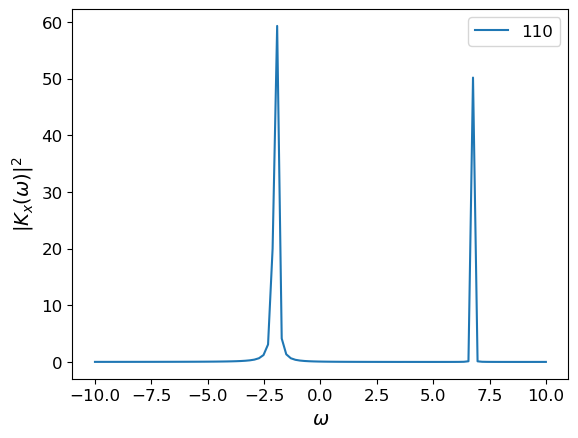

In [23]:
plt.plot(z, np.abs(K_110) ** 2, label='110')
plt.xlabel("$\\omega$")
plt.ylabel("$|K_x(\\omega)|^2$")
plt.legend()